# Humor Classification (6 classes) avec Llama 3-8B (GGUF, local)

Input : data/newyorker_caption_contest/contests.json
	
	•	Champs utilisés : image_descriptions, image_uncanny_descriptions, questions
	
	•	Modèle : Llama 3-8B fine-tuné (humour) — inférence locale via llama-cpp-python
	
	•	Sortie : data/GoogleTrends/humor_labels_llama3_q4km.csv (labels par texte)


In [ ]:
import json, pathlib
import pandas as pd

# === Paths ===
PATH = pathlib.Path("data/newyorker_caption_contest/contests.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "questions"]  # ajoute "image_locations" si utile

def load_records(path: pathlib.Path):
    txt = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(txt)
    except json.JSONDecodeError:
        recs = []
        with path.open(encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    recs.append(json.loads(line))
        return recs
    if isinstance(obj, list):
        return obj
    if isinstance(obj, dict):
        return obj.get("contests", [obj])
    raise ValueError("Unsupported JSON")

def collect_text_rows(records, fields):
    rows = []
    for r in records:
        cid = r.get("contest_id")
        meta = r.get("metadata") or {}
        for f in fields:
            v = meta.get(f)
            if isinstance(v, list):
                for s in v:
                    if isinstance(s, str) and s.strip():
                        rows.append({"contest_id": cid, "field": f, "text": s.strip()})
            elif isinstance(v, str) and v.strip():
                rows.append({"contest_id": cid, "field": f, "text": v.strip()})
    return pd.DataFrame(rows, columns=["contest_id","field","text"])

records = load_records(PATH)
df_text = collect_text_rows(records, FIELDS)
print(f"Nb de textes: {len(df_text)}")
df_text.head()

# Model & Prompt

### Humor types classification ("irony", "sarcasm", "exaggeration","incongruity-absurdity", "self-deprecating", "wit-surprise")

In [7]:
# Repo: https://huggingface.co/AnsonLau/llama3-8b-fine-tuned-humor-classification-q4_k_m
# File: llama3-8b-fine-tuned-humor-classification-q4_k_m-unsloth.Q4_K_M.gguf
# Saved to: models/llama3_humor_q4km.gguf

# Install & import llama-cpp-python (works on macOS/Apple Silicon & Intel)
import sys, subprocess, pkgutil
if pkgutil.find_loader("llama_cpp") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", "pip", "setuptools", "wheel"])
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "llama-cpp-python==0.2.90"])

from llama_cpp import Llama
print("llama_cpp is ready")
from huggingface_hub import hf_hub_download

model_path = hf_hub_download(
    repo_id="AnsonLau/llama3-8b-fine-tuned-humor-classification-q4_k_m",
    filename="llama3-8b-fine-tuned-humor-classification-q4_k_m-unsloth.Q4_K_M.gguf",
    local_files_only=False,
    resume_download=True,
)

llm = Llama(model_path=model_path, n_ctx=4096)

llama_cpp is ready


llama3-8b-fine-tuned-humor-classificatio(…):   0%|          | 0.00/4.92G [00:00<?, ?B/s]

llama_model_loader: loaded meta data with 22 key-value pairs and 291 tensors from /Users/yann/.cache/huggingface/hub/models--AnsonLau--llama3-8b-fine-tuned-humor-classification-q4_k_m/snapshots/d0d3e743739f3546cba4c7803de150dc07e73009/llama3-8b-fine-tuned-humor-classification-q4_k_m-unsloth.Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values. Note: KV overrides do not apply in this output.
llama_model_loader: - kv   0:                       general.architecture str              = llama
llama_model_loader: - kv   1:                               general.name str              = llama3-8b-fine-tuned-humor-classifica...
llama_model_loader: - kv   2:                           llama.vocab_size u32              = 128256
llama_model_loader: - kv   3:                       llama.context_length u32              = 8192
llama_model_loader: - kv   4:                     llama.embedding_length u32              = 4096
llama_model_loader: - kv   5:                  

In [15]:
# --- Build a new contests.json with LLM humor labels (robust to empty outputs) ---
import json, pathlib, re, time
from copy import deepcopy

# === Paths ===
IN_PATH  = pathlib.Path("data/newyorker_caption_contest/contests.json")
OUT_PATH = pathlib.Path("data/newyorker_caption_contest/contests_with_humor.json")

# === Fields to classify ===
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "questions"]

# === Require an existing llm instance ===
try:
    llm  # noqa: F821
except NameError:
    raise RuntimeError(
        "No 'llm' instance found. Create it first, e.g. with llama_cpp + hf_hub_download, then rerun this cell."
    )

# === Classes & prompt ===
CLASSES = [
    "irony", "sarcasm", "exaggeration",
    "incongruity-absurdity", "self-deprecating", "wit-surprise"
]

PROMPT_TMPL = """Classify the following text into one of the classes.
Here are the six types of classes:
Irony - Irony relies on a gap between the literal meaning and the intended meaning, creating a humorous twist or reversal.
Sarcasm - Sarcasm involves using irony to mock, criticize, or convey contempt.
Exaggeration - Exaggeration involves magnifying or overstating something beyond its normal or realistic proportions.
Incongruity-Absurdity - Incongruity refers to unexpected or contradictory elements combined in a humorous way; Absurdity involves illogical or nonsensical ideas.
Self-deprecating - Self-deprecating humor makes fun of oneself or highlights one’s own flaws in a lighthearted manner.
Wit-Surprise - Wit is clever, quick humor; Surprise introduces unexpected elements or twists that catch the audience off guard.
You ought to focus more on classifying irony and sarcasm.
Let's think step by step.

Text: {text}

### Response:"""

def normalize_label(raw: str) -> str:
    """Map model output to one of the 6 class names; else 'unknown'."""
    if not raw:
        return "unknown"
    s = raw.strip()
    if not s:
        return "unknown"
    s = s.splitlines()[0].strip().lower()
    s = re.sub(r"[^a-z\- ]", "", s)
    s = s.replace("_", "-").replace("  ", " ").strip()
    s = s.replace("self deprecating", "self-deprecating")
    s = s.replace("incongruity absurdity", "incongruity-absurdity")
    if s == "wit": s = "wit-surprise"
    if s == "selfdeprecating": s = "self-deprecating"
    if s == "incongruityabsurdity": s = "incongruity-absurdity"
    return s if s in CLASSES else "unknown"

def classify_one(text: str, max_tokens=8, temperature=0.0, retries=2, sleep=0.2):
    """Call the LLM and return a normalized single label, with retries and safe fallbacks."""
    prompt = PROMPT_TMPL.format(text=text)
    for attempt in range(retries + 1):
        try:
            out = llm(prompt, max_tokens=max_tokens, temperature=temperature, stop=["\n", "###"])
            # Defensive parsing of llama-cpp output
            choices = out.get("choices") if isinstance(out, dict) else None
            raw = ""
            if choices and isinstance(choices, list) and choices:
                raw = choices[0].get("text", "")
            label = normalize_label(raw)
            if label != "unknown" or attempt == retries:
                return label
        except Exception:
            if attempt == retries:
                return "unknown"
        time.sleep(sleep * (attempt + 1))
    return "unknown"

# === Load original JSON, preserving top-level shape ===
raw = json.loads(IN_PATH.read_text(encoding="utf-8"))
if isinstance(raw, dict) and "contests" in raw and isinstance(raw["contests"], list):
    top_is_dict = True
    contests = raw["contests"]
elif isinstance(raw, list):
    top_is_dict = False
    contests = raw
else:
    raise ValueError("Unsupported top-level JSON structure (expect dict with 'contests' or a list).")

updated = deepcopy(contests)

# === Classify and inject labels (ALWAYS store lists) ===
for rec in updated:
    meta = rec.get("metadata")
    if meta is None:
        meta = {}
        rec["metadata"] = meta

    llm_block = meta.get("llm_humor_labels", {})
    for field in FIELDS:
        v = meta.get(field, None)
        if isinstance(v, list):
            labels = [
                classify_one(s) if isinstance(s, str) and s.strip() else "unknown"
                for s in v
            ]
        elif isinstance(v, str):
            labels = [classify_one(v.strip())] if v.strip() else []
        else:
            labels = []  # missing or None -> empty list
        llm_block[field] = labels

    meta["llm_humor_labels"] = llm_block

# === Write back with original top-level container ===
out_obj = {"contests": updated} if top_is_dict else updated
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
OUT_PATH.write_text(json.dumps(out_obj, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Saved updated file with LLM labels -> {OUT_PATH}")

root ::= [i] [r] [o] [n] [y] | [s] [a] [r] [c] [a] [s] [m] | [e] [x] [a] [g] [g] [e] [r] [a] [t] [i] [o] [n] | [i] [n] [c] [o] [n] [g] [r] [u] [i] [t] [y] [-] [a] [b] [s] [u] [r] [d] [i] [t] [y] | [s] [e] [l] [f] [-] [d] [e] [p] [r] [e] [c] [a] [t] [i] [n] [g] | [w] [i] [t] [-] [s] [u] [r] [p] [r] [i] [s] [e] 


Llama.generate: 44 prefix-match hit, remaining 31 prompt tokens to eval

llama_print_timings:        load time =   10851.03 ms
llama_print_timings:      sample time =      40.85 ms /     4 runs   (   10.21 ms per token,    97.91 tokens per second)
llama_print_timings: prompt eval time =   51196.73 ms /    45 tokens ( 1137.71 ms per token,     0.88 tokens per second)
llama_print_timings:        eval time =     348.20 ms /     3 runs   (  116.07 ms per token,     8.62 tokens per second)
llama_print_timings:       total time =    2887.46 ms /    48 tokens
Llama.generate: 47 prefix-match hit, remaining 17 prompt tokens to eval

llama_print_timings:        load time =   10851.03 ms
llama_print_timings:      sample time =      28.76 ms /     4 runs   (    7.19 ms per token,   139.10 tokens per second)
llama_print_timings: prompt eval time =     686.25 ms /    17 tokens (   40.37 ms per token,    24.77 tokens per second)
llama_print_timings:        eval time =     235.57 ms /     3 runs   (  

Saved updated file with LLM labels -> data/newyorker_caption_contest/contests_with_humor.json


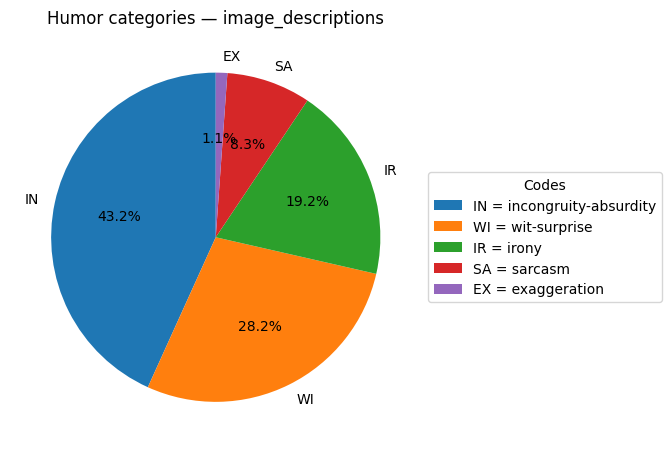

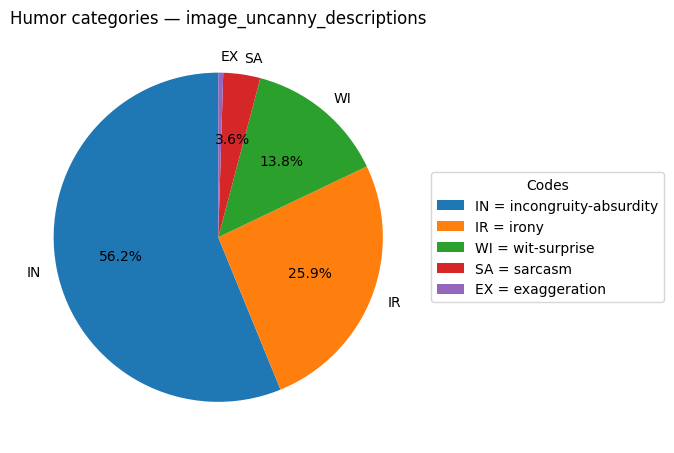

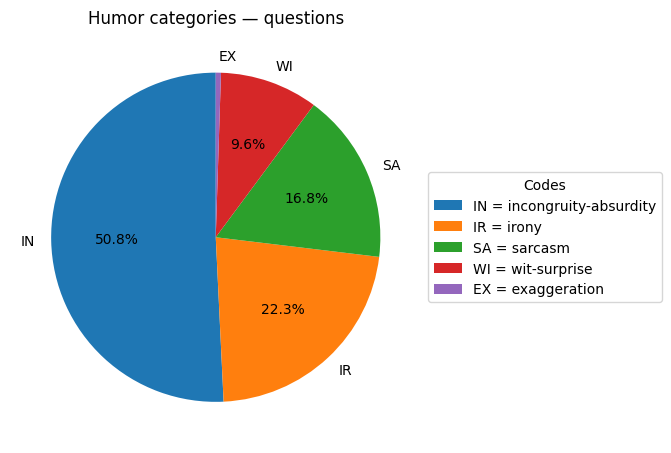

In [20]:
import json, pathlib, re
from collections import Counter
import matplotlib.pyplot as plt

# --- Config ---
PATH = pathlib.Path("data/newyorker_caption_contest/contests_with_humor.json")
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "questions"]
INCLUDE_UNKNOWN = False   # set False to drop "unknown" from the pies
MIN_SLICE_COUNT = 1      # drop slices with fewer than this many items

# helper: first two letters (A–Z) uppercase
def two_letter_code(label: str) -> str:
    s = re.sub(r"[^A-Za-z]", "", (label or ""))
    return (s[:2].upper() if len(s) >= 2 else s.upper() or "??")

# --- Load ---
obj = json.loads(PATH.read_text(encoding="utf-8"))
contests = obj["contests"] if isinstance(obj, dict) and "contests" in obj else obj

# --- Count labels per field ---
counts_per_field = {f: Counter() for f in FIELDS}
for rec in contests:
    meta = rec.get("metadata") or {}
    llm_block = meta.get("llm_humor_labels") or {}
    for f in FIELDS:
        labels = llm_block.get(f, [])
        if isinstance(labels, list):
            for lab in labels:
                lab = (lab or "").strip().lower()
                if lab:
                    counts_per_field[f][lab] += 1

# --- Plot one pie per field with 2-letter labels ---
for f in FIELDS:
    counts = counts_per_field[f].copy()

    if not INCLUDE_UNKNOWN and "unknown" in counts:
        del counts["unknown"]

    # optionally drop tiny slices
    if MIN_SLICE_COUNT > 1:
        for k in list(counts.keys()):
            if counts[k] < MIN_SLICE_COUNT:
                del counts[k]

    if not counts:
        print(f"[{f}] No labels to plot.")
        continue

    # sort by frequency desc, then name
    items = sorted(counts.items(), key=lambda kv: (-kv[1], kv[0]))
    full_labels = [kv[0] for kv in items]
    sizes = [kv[1] for kv in items]
    short_labels = [two_letter_code(lbl) for lbl in full_labels]

    plt.figure(figsize=(6.8, 6.8))
    wedges, texts, autotexts = plt.pie(
        sizes,
        labels=short_labels,
        autopct=lambda p: f"{p:.1f}%" if p >= 1 else "",
        startangle=90
    )
    plt.title(f"Humor categories — {f}")

    # Legend mapping 2-letter code -> full label
    legend_labels = [f"{s} = {l}" for s, l in zip(short_labels, full_labels)]
    plt.legend(wedges, legend_labels, title="Codes", loc="center left", bbox_to_anchor=(1.0, 0.5))
    plt.tight_layout()
    plt.show()

In [18]:
import json, pathlib
from collections import Counter

PATH = pathlib.Path("data/newyorker_caption_contest/contests_with_humor.json")
FIELDS = ["image_descriptions","image_uncanny_descriptions","questions"]

obj = json.loads(PATH.read_text(encoding="utf-8"))
contests = obj["contests"] if isinstance(obj, dict) else obj

for f in FIELDS:
    c = Counter()
    tot = 0
    for r in contests:
        labs = (r.get("metadata",{}).get("llm_humor_labels",{}).get(f, []) or [])
        c.update([x or "" for x in labs])
        tot += len(labs)
    unk = c.get("unknown", 0)
    print(f"{f}: unknown = {unk}/{tot} ({(unk/max(tot,1))*100:.1f}%)")

image_descriptions: unknown = 264/530 (49.8%)
image_uncanny_descriptions: unknown = 117/530 (22.1%)
questions: unknown = 388/585 (66.3%)


### Text classification (POS, NEU, NEG)

In [21]:
# Add POS/NEU/NEG sentiment to the SAME JSON file (in-place), alongside existing metadata
import json, pathlib, sys, subprocess, pkgutil
from collections import Counter

# --- Paths ---
INOUT_PATH = pathlib.Path("data/newyorker_caption_contest/contests_with_humor.json")  # update in place
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "questions"]

# --- Install deps if needed ---
if pkgutil.find_loader("transformers") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", "transformers>=4.40", "torch"])

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TextClassificationPipeline

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
pipe = TextClassificationPipeline(model=model, tokenizer=tokenizer, return_all_scores=False, truncation=True)

def batched(iterable, n):
    for i in range(0, len(iterable), n):
        yield iterable[i:i+n]

# --- Load JSON ---
obj = json.loads(INOUT_PATH.read_text(encoding="utf-8"))
contests = obj["contests"] if isinstance(obj, dict) else obj

# --- Prepare flat lists per field (to batch efficiently) and spans to map back ---
field_texts = {f: [] for f in FIELDS}
field_spans = {f: [] for f in FIELDS}  # per contest: (start_idx, end_idx)
for rec in contests:
    meta = rec.get("metadata") or {}
    for f in FIELDS:
        vals = meta.get(f, [])
        if isinstance(vals, str):
            vals = [vals]
        start = len(field_texts[f])
        texts = [(v if isinstance(v, str) and v.strip() else "") for v in vals]
        field_texts[f].extend(texts)
        end = len(field_texts[f])
        field_spans[f].append((start, end))

# --- Run sentiment per field (batched) ---
field_preds = {}
for f in FIELDS:
    texts = field_texts[f]
    preds = []
    if texts:
        for chunk in batched(texts, 64):
            out = pipe(chunk)
            preds.extend([(o["label"].lower(), float(o["score"])) if isinstance(o, dict) else ("unknown", 0.0) for o in out])
    field_preds[f] = preds

# --- Inject llm_sentiment into metadata  ---
for rec_idx, rec in enumerate(contests):
    meta = rec.get("metadata") or {}
    sentiments = {}
    for f in FIELDS:
        start, end = field_spans[f][rec_idx]
        preds_slice = field_preds[f][start:end] if start < end else []
        vals = meta.get(f, [])
        if isinstance(vals, str):
            vals = [vals]
        labels = []
        for text, (lbl, _score) in zip(vals, preds_slice):
            if isinstance(text, str) and text.strip():
                labels.append(lbl)
            else:
                labels.append("unknown")
        sentiments[f] = labels  
    meta["llm_sentiment"] = sentiments
    rec["metadata"] = meta

if isinstance(obj, dict):
    obj["contests"] = contests
else:
    obj = contests

INOUT_PATH.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"Saved sentiment labels into: {INOUT_PATH}")

for f in FIELDS:
    c = Counter()
    for r in contests:
        labs = (r.get("metadata", {}).get("llm_sentiment", {}).get(f, []) or [])
        c.update(labs)
    total = sum(c.values()) or 1
    print(f"{f} -> pos:{c.get('positive',0)} neu:{c.get('neutral',0)} neg:{c.get('negative',0)} unk:{c.get('unknown',0)}  (total={total})")

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0
/Users/yann/anaconda3/envs/myenv/lib/python3.11/site-packages/transformers/pipelines/text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Saved sentiment labels into: data/newyorker_caption_contest/contests_with_humor.json
image_descriptions -> pos:16 neu:427 neg:87 unk:0  (total=530)
image_uncanny_descriptions -> pos:10 neu:319 neg:201 unk:0  (total=530)
questions -> pos:0 neu:378 neg:207 unk:0  (total=585)


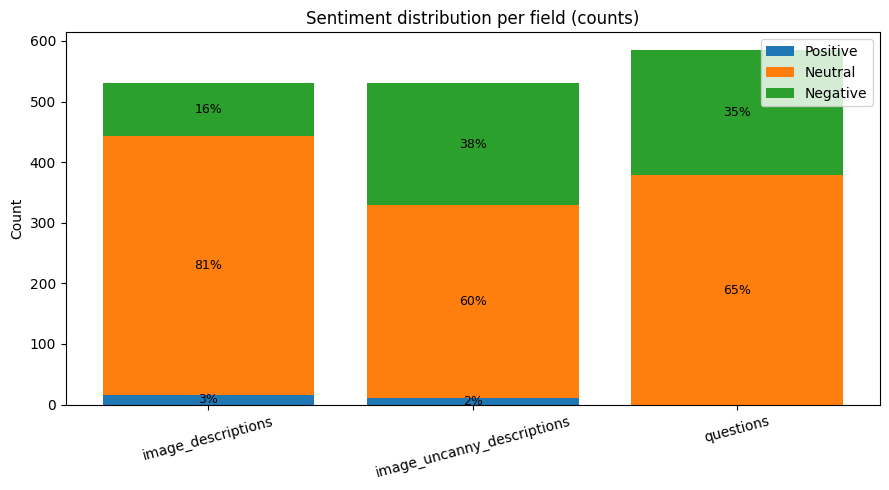


=== image_descriptions ===
positive:     16  (  3.0%)
 neutral:    427  ( 80.6%)
negative:     87  ( 16.4%)
   TOTAL:    530

=== image_uncanny_descriptions ===
positive:     10  (  1.9%)
 neutral:    319  ( 60.2%)
negative:    201  ( 37.9%)
   TOTAL:    530

=== questions ===
positive:      0  (  0.0%)
 neutral:    378  ( 64.6%)
negative:    207  ( 35.4%)
   TOTAL:    585

=== OVERALL ===
positive:     26  (  1.6%)
 neutral:   1124  ( 68.3%)
negative:    495  ( 30.1%)
   TOTAL:   1645


In [24]:
import json, pathlib
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# --- Config ---
PATH = pathlib.Path("data/newyorker_caption_contest/contests_with_humor.json")  # same JSON you updated
FIELDS = ["image_descriptions", "image_uncanny_descriptions", "questions"]
INCLUDE_UNKNOWN = False  # set True to include "unknown" in the bars

# --- Load ---
obj = json.loads(PATH.read_text(encoding="utf-8"))
contests = obj["contests"] if isinstance(obj, dict) else obj

# --- Aggregate counts per field ---
order = ["positive", "neutral", "negative"] + (["unknown"] if INCLUDE_UNKNOWN else [])
counts = {f: Counter() for f in FIELDS}

for rec in contests:
    meta = rec.get("metadata", {})
    sent = meta.get("llm_sentiment", {})
    for f in FIELDS:
        labs = sent.get(f, [])
        counts[f].update(labs)

# Ensure all keys exist
for f in FIELDS:
    for lab in order:
        counts[f][lab] = counts[f].get(lab, 0)

# --- Build arrays for plotting ---
totals = np.array([sum(counts[f][k] for k in order) for f in FIELDS], dtype=float)
# Avoid div by zero
totals[totals == 0] = 1.0

data = {k: np.array([counts[f][k] for f in FIELDS], dtype=float) for k in order}
perc = {k: (data[k] / totals) for k in order}

# --- Stacked bar (counts on left axis, % on top of bars) ---
fig, ax = plt.subplots(figsize=(9, 5))
bottom = np.zeros(len(FIELDS), dtype=float)

for k in ["positive", "neutral", "negative"] + (["unknown"] if INCLUDE_UNKNOWN else []):
    ax.bar(FIELDS, data[k], bottom=bottom, label=k.capitalize())
    bottom += data[k]

ax.set_title("Sentiment distribution per field (counts)")
ax.set_ylabel("Count")
ax.legend(loc="upper right")
plt.xticks(rotation=15)
plt.tight_layout()

# Annotate % on each bar segment (optional, comment out if too busy)
for i, f in enumerate(FIELDS):
    cum = 0.0
    for k in ["positive", "neutral", "negative"] + (["unknown"] if INCLUDE_UNKNOWN else []):
        h = data[k][i]
        if h > 0:
            pct = 100 * perc[k][i]
            ax.text(i, cum + h/2, f"{pct:.0f}%", ha="center", va="center", fontsize=9)
            cum += h

plt.show()

def summarize_counts(counter, include_unknown):
    keys = ["positive", "neutral", "negative"] + (["unknown"] if include_unknown else [])
    total = sum(counter[k] for k in keys)
    if total == 0:
        return keys, [0]*len(keys), total, [0.0]*len(keys)
    counts = [counter.get(k, 0) for k in keys]
    perc   = [100.0 * c / total if total > 0 else 0.0 for c in counts]
    return keys, counts, total, perc

# --- Per-field ---
overall = Counter()
for f in FIELDS:
    c = Counter()
    for rec in contests:
        labs = (rec.get("metadata", {}).get("llm_sentiment", {}).get(f, []) or [])
        c.update(labs)
    # Optionally drop unknown from totals/perc
    if not INCLUDE_UNKNOWN:
        if "unknown" in c:
            del c["unknown"]
    keys, counts, total, perc = summarize_counts(c, INCLUDE_UNKNOWN)
    print(f"\n=== {f} ===")
    for k, n, p in zip(keys, counts, perc):
        print(f"{k:>8s}: {n:6d}  ({p:5.1f}%)")
    print(f"{'TOTAL':>8s}: {total:6d}")

    overall.update(c)

# --- Overall ---
keys, counts, total, perc = summarize_counts(overall, INCLUDE_UNKNOWN)
print("\n=== OVERALL ===")
for k, n, p in zip(keys, counts, perc):
    print(f"{k:>8s}: {n:6d}  ({p:5.1f}%)")
print(f"{'TOTAL':>8s}: {total:6d}")